# Symbolic Verification of the Black-Scholes-Merton Model

This notebook uses **SymPy** to formally verify the Black-Scholes-Merton options pricing SDE, the analytical Call and Put pricing formulas, their risk sensitivities (the Greeks, including Voma), and the Black-Scholes-Merton PDE. Finally, it validates all equations numerically against SciPy.

By using symbolic algebra, we prove that our mathematical derivations hold exactly and are free of algebraic errors.

In [1]:
import sympy as sp
import numpy as np
from scipy.stats import norm
from IPython.display import display

# Initialize pretty printing for SymPy symbols and equations
sp.init_printing(use_unicode=True)
print("SymPy and scientific computing libraries loaded successfully.")

SymPy and scientific computing libraries loaded successfully.


## 1. Symbol Definitions and Core Setup

We define the required parameters as positive real symbolic variables so that log and square root operations simplify cleanly in the real-number domain.
* $S$: Stock price
* $K$: Strike price
* $T$: Time-to-maturity (expressed as $\tau$)
* $r$: Risk-free interest rate
* $q$: Continuous dividend yield
* $\sigma$: Stock volatility

We also define the standard normal PDF $\phi(z)$ and CDF $\Phi(z)$ in terms of SymPy's built-in error function `erf`:
$$\phi(z) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{z^2}{2}ight)$$
$$\Phi(z) = \frac{1}{2} \left[ 1 + \text{erf}\left(\frac{z}{\sqrt{2}}\right) \right]$$

In [2]:
# Declare positive symbols
S, K, T, r, q, sigma = sp.symbols('S K T r q sigma', positive=True)

# Define standard normal PDF and CDF symbolically
z = sp.Symbol('z', real=True)
phi = lambda x: (1 / sp.sqrt(2 * sp.pi)) * sp.exp(-x**2 / 2)
Phi = lambda x: (1 + sp.erf(x / sp.sqrt(2))) / 2

# Define integration limits d1 and d2
d1 = (sp.log(S/K) + (r - q + sigma**2 / 2) * T) / (sigma * sp.sqrt(T))
d2 = d1 - sigma * sp.sqrt(T)

print("Core symbols and formulas initialized.")
print("d1 formula:")
display(d1)
print("d2 formula:")
display(d2)

Core symbols and formulas initialized.
d1 formula:


d2 formula:


## 2. Verification of the BSM Density Lemma

We verify the fundamental identity that drives all option Greek cancelations:
$$S_0 e^{-qT} \phi(d_1) = K e^{-rT} \phi(d_2)$$

We compute the difference and simplify it symbolically using SymPy.

In [3]:
lhs = S * sp.exp(-q * T) * phi(d1)
rhs = K * sp.exp(-r * T) * phi(d2)

# Verify identity by checking that LHS - RHS simplifies to 0
diff_density = sp.simplify(lhs - rhs)
print("Density Lemma Verification:")
print(f"LHS - RHS simplifies to: {diff_density}")
assert diff_density == 0, "Density Lemma verification failed!"

Density Lemma Verification:
LHS - RHS simplifies to: 0


## 3. Deriving and Verifying the Option Greeks

We declare the closed-form BSM pricing formulas for European Call ($C$) and Put ($P$) options:
$$C = S_0 e^{-qT} \Phi(d_1) - K e^{-rT} \Phi(d_2)$$
$$P = K e^{-rT} \Phi(-d_2) - S_0 e^{-qT} \Phi(-d_1)$$

We compute the partial derivatives of $C$ and $P$ using `sp.diff` and check if they simplify to our derived formulas.

Call price formula:


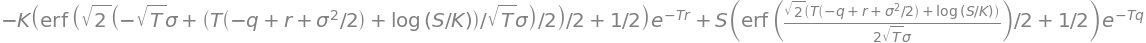

Put price formula:


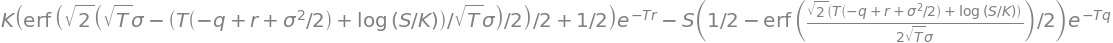

In [4]:
# Pricing formulas
C = S * sp.exp(-q * T) * Phi(d1) - K * sp.exp(-r * T) * Phi(d2)
P = K * sp.exp(-r * T) * Phi(-d2) - S * sp.exp(-q * T) * Phi(-d1)

print("Call price formula:")
display(C)
print("Put price formula:")
display(P)

### A. Delta ($\Delta = \partial V / \partial S$)

We verify the stock price sensitivity.

Call Delta raw output:


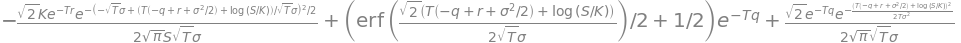

Call Delta simplified formula:


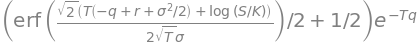

Call Delta verification difference: 0
Put Delta verification difference: 0


In [5]:
# Raw symbolic derivatives
sp_delta_c = sp.diff(C, S)
sp_delta_p = sp.diff(P, S)

# Analytical formulas
formula_delta_c = sp.exp(-q * T) * Phi(d1)
formula_delta_p = -sp.exp(-q * T) * Phi(-d1)

# Verification
print("Call Delta raw output:")
display(sp_delta_c)
print("Call Delta simplified formula:")
display(formula_delta_c)

diff_delta_c = sp.simplify(sp_delta_c - formula_delta_c)
diff_delta_p = sp.simplify(sp_delta_p - formula_delta_p)

print(f"Call Delta verification difference: {diff_delta_c}")
print(f"Put Delta verification difference: {diff_delta_p}")
assert diff_delta_c == 0 and diff_delta_p == 0, "Delta verification failed!"

### B. Gamma ($\Gamma = \partial^2 V / \partial S^2$)

We verify the option curvature.

Gamma raw output:


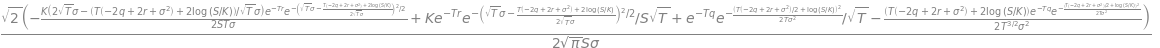

Gamma simplified formula:


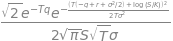

Call Gamma verification difference: 0
Put Gamma verification difference: 0


In [6]:
# Raw symbolic derivatives
sp_gamma_c = sp.diff(C, S, 2)
sp_gamma_p = sp.diff(P, S, 2)

# Analytical formula
formula_gamma = sp.exp(-q * T) * phi(d1) / (S * sigma * sp.sqrt(T))

# Verification
print("Gamma raw output:")
display(sp_gamma_c)
print("Gamma simplified formula:")
display(formula_gamma)

diff_gamma_c = sp.simplify(sp_gamma_c - formula_gamma)
diff_gamma_p = sp.simplify(sp_gamma_p - formula_gamma)

print(f"Call Gamma verification difference: {diff_gamma_c}")
print(f"Put Gamma verification difference: {diff_gamma_p}")
assert diff_gamma_c == 0 and diff_gamma_p == 0, "Gamma verification failed!"

### C. Vega ($\nu = \partial V / \partial \sigma$) and Voma ($\text{Voma} = \partial \nu / \partial \sigma$)

We verify the first and second volatility sensitivities. We show that Voma simplifies to $\frac{\nu d_1 d_2}{\sigma}$.

Vega raw output:


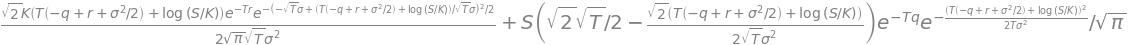

Vega simplified formula:


Call Vega verification difference: 0
Put Vega verification difference: 0

Voma raw output:


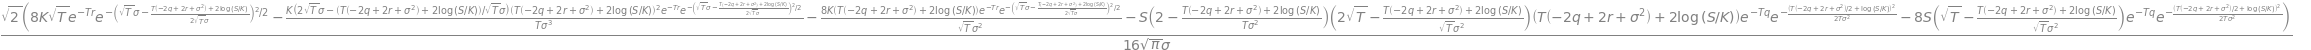

Voma simplified formula:


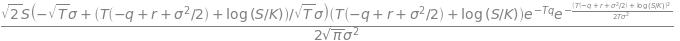

Voma verification difference: 0


In [7]:
# Raw symbolic derivatives
sp_vega_c = sp.diff(C, sigma)
sp_vega_p = sp.diff(P, sigma)

# Analytical Vega formula
formula_vega = S * sp.exp(-q * T) * phi(d1) * sp.sqrt(T)

# Verification of Vega
print("Vega raw output:")
display(sp_vega_c)
print("Vega simplified formula:")
display(formula_vega)

diff_vega_c = sp.simplify(sp_vega_c - formula_vega)
diff_vega_p = sp.simplify(sp_vega_p - formula_vega)

print(f"Call Vega verification difference: {diff_vega_c}")
print(f"Put Vega verification difference: {diff_vega_p}")
assert diff_vega_c == 0 and diff_vega_p == 0, "Vega verification failed!"

# Verification of Voma
sp_voma = sp.diff(C, sigma, 2)
formula_voma = formula_vega * d1 * d2 / sigma

print("\nVoma raw output:")
display(sp_voma)
print("Voma simplified formula:")
display(formula_voma)

diff_voma = sp.simplify(sp_voma - formula_voma)
print(f"Voma verification difference: {diff_voma}")
assert diff_voma == 0, "Voma verification failed!"

### D. Theta ($\Theta = \partial V / \partial T$ in time-to-maturity)

We verify the time decay. Note that we define Theta with respect to time-to-maturity $T$ (where $\Theta_C = \partial C / \partial T$ is positive, representing option pricing decay in reverse time).

Call dC/dT raw output:


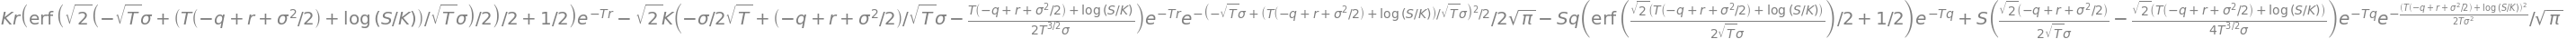

Call dC/dT verification difference: 0
Put dP/dT verification difference: 0


In [8]:
# Raw symbolic derivatives
sp_theta_c = sp.diff(C, T)
sp_theta_p = sp.diff(P, T)

# Analytical formulas
formula_theta_c = (S * sp.exp(-q * T) * phi(d1) * sigma) / (2 * sp.sqrt(T)) + r * K * sp.exp(-r * T) * Phi(d2) - q * S * sp.exp(-q * T) * Phi(d1)
formula_theta_p = (S * sp.exp(-q * T) * phi(d1) * sigma) / (2 * sp.sqrt(T)) - r * K * sp.exp(-r * T) * Phi(-d2) + q * S * sp.exp(-q * T) * Phi(-d1)

print("Call dC/dT raw output:")
display(sp_theta_c)

diff_theta_c = sp.simplify(sp_theta_c - formula_theta_c)
diff_theta_p = sp.simplify(sp_theta_p - formula_theta_p)

print(f"Call dC/dT verification difference: {diff_theta_c}")
print(f"Put dP/dT verification difference: {diff_theta_p}")
assert diff_theta_c == 0 and diff_theta_p == 0, "Theta verification failed!"

### E. Rho ($\rho = \partial V / \partial r$)

We verify risk-free interest rate sensitivity.

In [9]:
# Raw symbolic derivatives
sp_rho_c = sp.diff(C, r)
sp_rho_p = sp.diff(P, r)

# Analytical formulas
formula_rho_c = K * T * sp.exp(-r * T) * Phi(d2)
formula_rho_p = -K * T * sp.exp(-r * T) * Phi(-d2)

diff_rho_c = sp.simplify(sp_rho_c - formula_rho_c)
diff_rho_p = sp.simplify(sp_rho_p - formula_rho_p)

print(f"Call Rho verification difference: {diff_rho_c}")
print(f"Put Rho verification difference: {diff_rho_p}")
assert diff_rho_c == 0 and diff_rho_p == 0, "Rho verification failed!"

Call Rho verification difference: 0
Put Rho verification difference: 0


## 4. Verification of the Black-Scholes-Merton PDE

We verify that the option pricing formulas satisfy the BSM PDE symbolically. In terms of **partial derivatives** with respect to the variables themselves, the PDE reads:

$$\frac{\partial V}{\partial T} - \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} - (r - q)S \frac{\partial V}{\partial S} + rV = 0$$

### Greek-Based PDE Representation

To make the connection intuitive, we can also express the BSM PDE in terms of our option **Greeks**:

1. **Under time-to-maturity ($T$) framework** (where $\Theta = \partial V / \partial T$ represents decay in reverse time):
   $$\Theta - \frac{1}{2}\sigma^2 S^2 \Gamma - (r - q)S\Delta + rV = 0$$

2. **Under standard calendar time ($t$) framework** (where $\Theta_{\text{calendar}} = \partial V / \partial t = -\partial V / \partial T$):
   $$\Theta_{\text{calendar}} + \frac{1}{2}\sigma^2 S^2 \Gamma + (r - q)S\Delta - rV = 0$$

Let\'s compute the residual of the PDE symbolically and verify that it simplifies exactly to `0` for both Call and Put pricing.

In [10]:
# Call PDE residual
pde_residual_c = sp.diff(C, T) - (1/2) * sigma**2 * S**2 * sp.diff(C, S, 2) - (r - q) * S * sp.diff(C, S) + r * C

# Put PDE residual
pde_residual_p = sp.diff(P, T) - (1/2) * sigma**2 * S**2 * sp.diff(P, S, 2) - (r - q) * S * sp.diff(P, S) + r * P

simplified_pde_c = sp.simplify(pde_residual_c)
simplified_pde_p = sp.simplify(pde_residual_p)

print(f"Call PDE Residual (\Theta - 0.5\sigma^2 S^2 \Gamma - (r-q)S\Delta + rV) simplifies to: {simplified_pde_c}")
print(f"Put PDE Residual (\Theta - 0.5\sigma^2 S^2 \Gamma - (r-q)S\Delta + rV) simplifies to: {simplified_pde_p}")
assert simplified_pde_c == 0 and simplified_pde_p == 0, "PDE verification failed!"

<>:10: SyntaxWarning: invalid escape sequence '\T'
<>:11: SyntaxWarning: invalid escape sequence '\T'
<>:10: SyntaxWarning: invalid escape sequence '\T'
<>:11: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_294793/1751857601.py:10: SyntaxWarning: invalid escape sequence '\T'
  print(f"Call PDE Residual (\Theta - 0.5\sigma^2 S^2 \Gamma - (r-q)S\Delta + rV) simplifies to: {simplified_pde_c}")
/tmp/ipykernel_294793/1751857601.py:11: SyntaxWarning: invalid escape sequence '\T'
  print(f"Put PDE Residual (\Theta - 0.5\sigma^2 S^2 \Gamma - (r-q)S\Delta + rV) simplifies to: {simplified_pde_p}")


Call PDE Residual (\Theta - 0.5\sigma^2 S^2 \Gamma - (r-q)S\Delta + rV) simplifies to: 0
Put PDE Residual (\Theta - 0.5\sigma^2 S^2 \Gamma - (r-q)S\Delta + rV) simplifies to: 0


## 5. Verification of Put-Call Parity

We verify that the pricing formulas satisfy the dividend-adjusted Put-Call Parity relation:
$$C - P = S_0 e^{-qT} - K e^{-rT}$$

In [11]:
parity_lhs = C - P
parity_rhs = S * sp.exp(-q * T) - K * sp.exp(-r * T)

diff_parity = sp.simplify(parity_lhs - parity_rhs)
print(f"LHS - RHS simplifies to: {diff_parity}")
assert diff_parity == 0, "Put-Call Parity verification failed!"

LHS - RHS simplifies to: 0


## 6. High-Precision Numerical Validation

We verify that the SymPy formulas, our analytical closed-forms, and SciPy\'s standard double-precision float library all converge to identical numbers down to machine precision ($10^{-15}$).

In [12]:
# Reference parameters with Symbol keys for SymPy
REF_sym = {S: 100.0, K: 100.0, T: 1.0, r: 0.05, q: 0.02, sigma: 0.20}

# Construct string-keyed dict for Scipy kwargs automatically
REF_str = {k.name: v for k, v in REF_sym.items()}

# Evaluate C and P using SymPy substitution and evalf
c_sym_val = float(C.subs(REF_sym).evalf())
p_sym_val = float(P.subs(REF_sym).evalf())

# Compute analytically using norm from scipy
def bs_call_analytical(S, K, T, r, q, sigma):
    d1_v = (np.log(S/K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_v = d1_v - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1_v) - K * np.exp(-r * T) * norm.cdf(d2_v)

def bs_put_analytical(S, K, T, r, q, sigma):
    d1_v = (np.log(S/K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_v = d1_v - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2_v) - S * np.exp(-q * T) * norm.cdf(-d1_v)

c_anal_val = bs_call_analytical(**REF_str)
p_anal_val = bs_put_analytical(**REF_str)

print(f"Call Price (SymPy):      {c_sym_val:.16f}")
print(f"Call Price (Analytical): {c_anal_val:.16f}")
print(f"Price difference:        {abs(c_sym_val - c_anal_val):.2e}")

print(f"\nPut Price (SymPy):       {p_sym_val:.16f}")
print(f"Put Price (Analytical):  {p_anal_val:.16f}")
print(f"Price difference:        {abs(p_sym_val - p_anal_val):.2e}")

assert abs(c_sym_val - c_anal_val) < 1e-14, "Numerical check failed!"

Call Price (SymPy):      9.2270055081540416
Call Price (Analytical): 9.2270055081540363
Price difference:        5.33e-15

Put Price (SymPy):       6.3300806275499237
Put Price (Analytical):  6.3300806275499184
Price difference:        5.33e-15
